In [3]:
# =============================================================================
# Program Name : HousePricePrediction_3DVisualization.py
#
# Objective:
# Build a Multiple Linear Regression model to predict House Prices
# and visualize the dataset and prediction model using 3D plots.
#
# Plot 1 : 3D Scatter Plot (Actual House Data)
# Plot 2 : 3D Scatter + Regression Surface (Predicted Model)
#
# Libraries:
#   numpy
#   pandas
#   matplotlib
#   scikit-learn
# =============================================================================

In [4]:
# =============================================================================
# STEP 1 - Import Required Libraries
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Required for creating 3D plots
from mpl_toolkits.mplot3d import Axes3D

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

In [5]:
# =============================================================================
# STEP 2 - Create Sample House Price Dataset
# =============================================================================
#
# Features:
#   Size       -> Area of the house (Square Feet)
#   Bedrooms   -> Number of Bedrooms
#
# Target:
#   Price      -> House Price
#
# =============================================================================

In [6]:
data = {
    "Size": [1000,1200,1500,1800,2000,
             2200,2500,2700,3000,3500],

    "Bedrooms": [2,2,3,3,4,
                 4,4,5,5,5],

    "Price": [200000,230000,280000,320000,360000,
              400000,430000,470000,520000,600000]
}

# Convert dictionary into DataFrame
df = pd.DataFrame(data)

print("\nHouse Price Dataset\n")
print(df)


House Price Dataset

   Size  Bedrooms   Price
0  1000         2  200000
1  1200         2  230000
2  1500         3  280000
3  1800         3  320000
4  2000         4  360000
5  2200         4  400000
6  2500         4  430000
7  2700         5  470000
8  3000         5  520000
9  3500         5  600000


In [7]:
# =============================================================================
# STEP 3 - Define Input Features and Target Variable
# =============================================================================

# Independent Variables (X)
X = df[["Size", "Bedrooms"]]

# Dependent Variable (y)
y = df["Price"]

In [8]:
# =============================================================================
# STEP 4 - Train Multiple Linear Regression Model
# =============================================================================

model = LinearRegression()

# Train the model
model.fit(X, y)

print("\nModel Training Completed Successfully")

print("\nIntercept :", model.intercept_)

print("\nCoefficients :")

print("Size       :", model.coef_[0])

print("Bedrooms   :", model.coef_[1])


Model Training Completed Successfully

Intercept : 35156.73981191206

Coefficients :
Size       : 154.07523510971794
Bedrooms   : 4357.366771159875


In [9]:
# =============================================================================
# STEP 5 - Create Mesh Grid
#
# The regression surface requires many combinations of
# Size and Bedrooms.
# =============================================================================

size_range = np.linspace(df["Size"].min(),
                         df["Size"].max(),
                         40)

bedroom_range = np.linspace(df["Bedrooms"].min(),
                            df["Bedrooms"].max(),
                            40)

# Create mesh grid
SizeGrid, BedroomGrid = np.meshgrid(size_range,
                                    bedroom_range)

In [10]:
# =============================================================================
# STEP 6 - Predict Price for Every Point on Mesh Grid
# =============================================================================

# Create a DataFrame with feature names
grid_points = pd.DataFrame({
    "Size": SizeGrid.ravel(),
    "Bedrooms": BedroomGrid.ravel()
})

# Predict prices
PredictedPrice = model.predict(grid_points)

# Convert predictions back to grid format
PriceSurface = PredictedPrice.reshape(SizeGrid.shape)

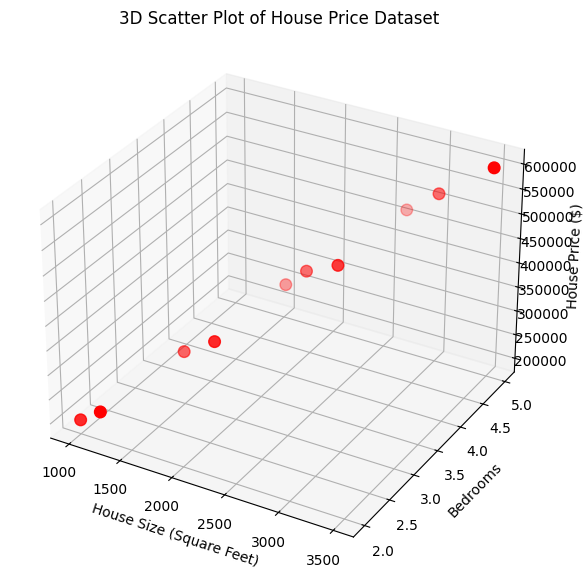

In [11]:
# =============================================================================
# PLOT 1
# 3D Scatter Plot
#
# Displays only the original dataset.
# =============================================================================

fig = plt.figure(figsize=(9,7))

ax = fig.add_subplot(111,
                     projection='3d')

# Plot actual data
ax.scatter(df["Size"],
           df["Bedrooms"],
           df["Price"],
           color="red",
           s=70)

ax.set_title("3D Scatter Plot of House Price Dataset")

ax.set_xlabel("House Size (Square Feet)")

ax.set_ylabel("Bedrooms")

ax.set_zlabel("House Price ($)")

plt.show()

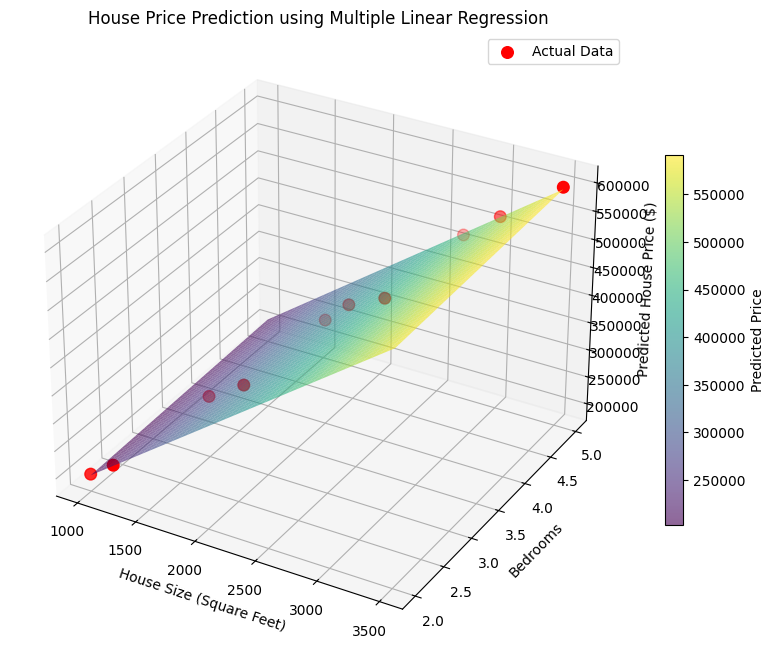

In [12]:
# =============================================================================
# PLOT 2
# Scatter Plot + Regression Surface
#
# Shows:
#   Red Dots  -> Actual House Prices
#   Surface   -> Predicted Regression Plane
# =============================================================================

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111,
                     projection='3d')

# Plot regression surface
surface = ax.plot_surface(SizeGrid,
                          BedroomGrid,
                          PriceSurface,
                          cmap="viridis",
                          alpha=0.6)

# Plot original data
ax.scatter(df["Size"],
           df["Bedrooms"],
           df["Price"],
           color="red",
           s=70,
           label="Actual Data")

# Labels
ax.set_title("House Price Prediction using Multiple Linear Regression")

ax.set_xlabel("House Size (Square Feet)")

ax.set_ylabel("Bedrooms")

ax.set_zlabel("Predicted House Price ($)")

# Display color scale
fig.colorbar(surface,
             shrink=0.6,
             label="Predicted Price")

# Display legend
ax.legend()

plt.show()

In [13]:
# =============================================================================
# STEP 7 - Predict Price of a New House
# =============================================================================

new_house = pd.DataFrame({
    "Size":[2400],
    "Bedrooms":[4]
})

predicted_price = model.predict(new_house)

print("\nPredicted Price of New House")

print("--------------------------------")

print("Bedrooms   :", new_house.loc[0, "Bedrooms"])

print("Predicted Price : ${:,.2f}".format(predicted_price[0]))


Predicted Price of New House
--------------------------------
Bedrooms   : 4
Predicted Price : $422,366.77
